In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
DATA_DIR = PROJECT_ROOT / "data" / "precipitation"

df = pd.read_csv(
    DATA_DIR / "Delhi_precip_2000_2010.txt",
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=["date", "precipitation"]
)

In [4]:
import os

print(os.getcwd())

/home/rupin/ERA5_LSTM_Project/notebooks/precipitation


In [5]:
import os

print(os.listdir())

['precipitation_EDA.ipynb']


In [6]:
df = pd.read_csv(
    "../../data/precipitation/Delhi_precip_2000_2010.txt",
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=["date", "precipitation"]
)

df["date"] = pd.to_datetime(df["date"])
df["precipitation"] = pd.to_numeric(
    df["precipitation"],
    errors="coerce"
)

In [7]:
print(df.head())

        date  precipitation
0 2000-01-01            0.0
1 2000-01-02            0.0
2 2000-01-03            0.0
3 2000-01-04            0.0
4 2000-01-05            0.0


In [8]:
print(df.tail())

           date  precipitation
4013 2010-12-27       0.000000
4014 2010-12-28       0.000000
4015 2010-12-29       0.559468
4016 2010-12-30       0.000000
4017 2010-12-31       0.590844


In [9]:
print(df.shape)

(4018, 2)


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4018 non-null   datetime64[us]
 1   precipitation  4018 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 62.9 KB


In [11]:
df.isnull().sum()

date             0
precipitation    0
dtype: int64

In [12]:
df.describe()

,date,precipitation
count,4018,4018.000000
mean,2005-07-01 12:00:00,1.356584
min,2000-01-01 00:00:00,0.000000
25%,2002-10-01 06:00:00,0.000000
50%,2005-07-01 12:00:00,0.000000
75%,2008-03-31 18:00:00,0.000000
max,2010-12-31 00:00:00,121.548508
std,NaN,6.405541


In [13]:
dry_days = (df["precipitation"] == 0).sum()

rainy_days = (df["precipitation"] > 0).sum()

print("Dry days :", dry_days)
print("Rainy days :", rainy_days)

Dry days : 3166
Rainy days : 852


In [14]:
print(
    "Dry days (%):",
    dry_days / len(df) * 100
)

print(
    "Rainy days (%):",
    rainy_days / len(df) * 100
)

Dry days (%): 78.7954206072673
Rainy days (%): 21.204579392732704


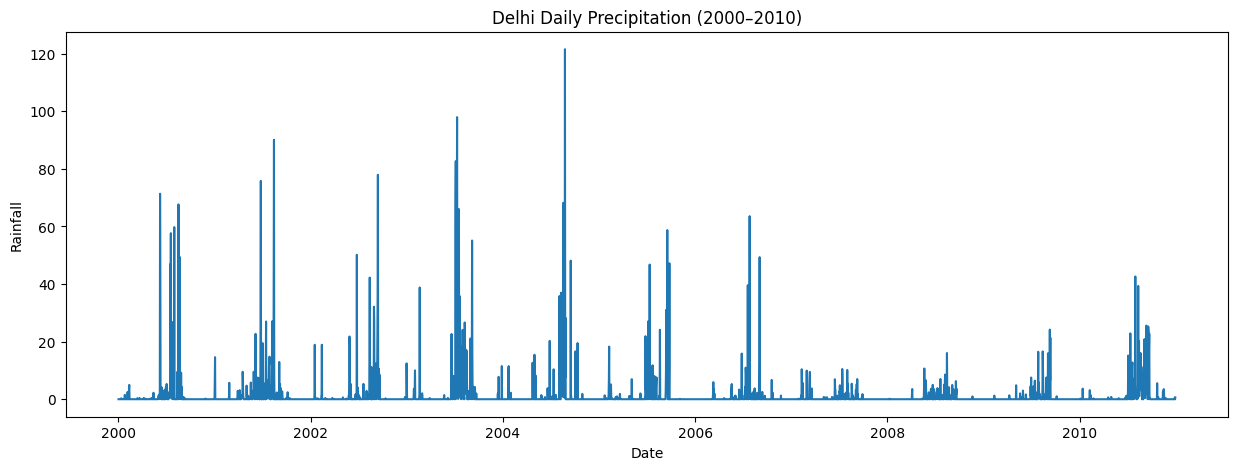

In [15]:
plt.figure(figsize=(15,5))

plt.plot(
    df["date"],
    df["precipitation"]
)

plt.title("Delhi Daily Precipitation (2000–2010)")
plt.xlabel("Date")
plt.ylabel("Rainfall")

plt.show()

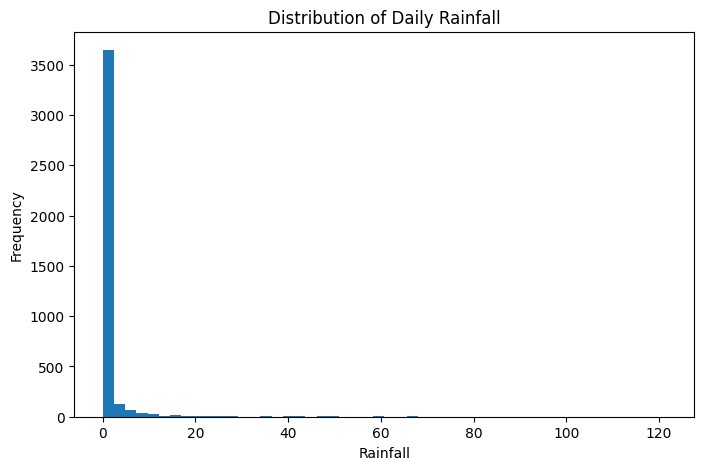

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    df["precipitation"],
    bins=50
)

plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Rainfall")

plt.show()

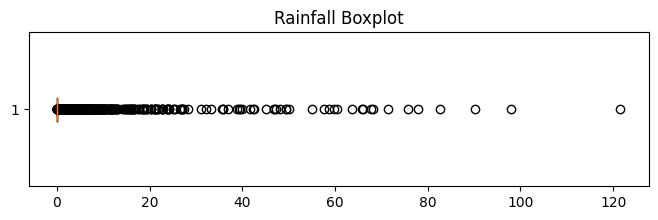

In [17]:
plt.figure(figsize=(8,2))

plt.boxplot(df["precipitation"], vert=False)

plt.title("Rainfall Boxplot")

plt.show()